In [ ]:
# Get real data work it out next time with him 


In [48]:
# =============================================================================
# LINEAR REGRESSION — "explain like I'm 10" (the story is only in these comments)
#
# Picture: each dot is one person (or one day).
#   x = something we know early  (example: how many hours they practiced)
#   y = something we want to guess (example: score on a test or game)
#
# A LINE is simple: y ≈ (slope) * x + (starting height). The computer picks
# slope + starting height so the line hugs the cloud of dots as well as it can.
#
# You will see: fake data → scatter plot → fitted line → "oops" plot → score
# → extra bit about "which columns actually help predict y?"
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [58]:
# read explore data 

import pandas as pd

df = pd.read_excel("ex2.xlsx")

df#.head()

,A,B,C,D,Y
0,-1,-1,-1,-1,45
1,1,-1,-1,-1,71
2,-1,1,-1,-1,48
3,1,1,-1,-1,65
4,-1,-1,1,-1,68
5,1,-1,1,-1,60
6,-1,1,1,-1,80
7,1,1,1,-1,65
8,-1,-1,-1,1,43
9,1,-1,-1,1,100


In [59]:
# Question : What can Explain 

In [60]:
#df['A']

In [66]:
# thing we want to predict

y = df['Y']

df['Apple'] = df['A']
df['MCSF'] = df['B']
df['TSLA'] = df['C']
df['AMZN'] = df['D']
df

df_1 = df[['Apple', 'MCSF'  ,'TSLA'   , 'AMZN' ,'Y' ]]
#df_1['Apple']  =df['Apple']

In [67]:
# variables used to predict Y -> THIS IS WHERE YOU FILTER COLUMNS 

# FILTER WAY TO DO IT WITH MULTIOPLE XS you need [[ ]]
X = df[['A', 'B', 'C', 'D']]

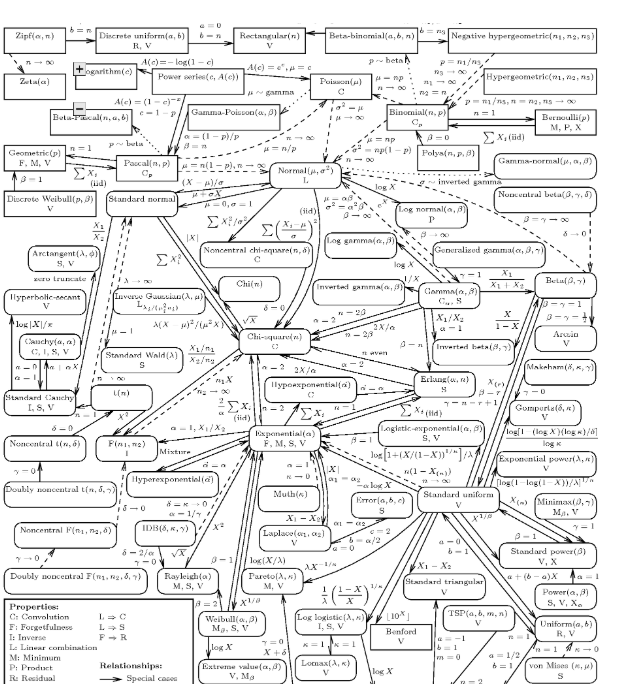

In [68]:
df_1

,Apple,MCSF,TSLA,AMZN,Y
0,-1,-1,-1,-1,45
1,1,-1,-1,-1,71
2,-1,1,-1,-1,48
3,1,1,-1,-1,65
4,-1,-1,1,-1,68
5,1,-1,1,-1,60
6,-1,1,1,-1,80
7,1,1,1,-1,65
8,-1,-1,-1,1,43
9,1,-1,-1,1,100


In [69]:
# PRe TEST -> to see how correlated the data is : 

In [70]:
df_1.corr().round(5)

# CORRELATION 

,Apple,MCSF,TSLA,AMZN,Y
Apple,1.00000,-0.00000,-0.00000,-0.00000,0.57131
MCSF,-0.00000,1.00000,-0.00000,0.00000,0.08256
TSLA,-0.00000,-0.00000,1.00000,0.00000,0.26089
AMZN,-0.00000,0.00000,0.00000,1.00000,0.38638
Y,0.57131,0.08256,0.26089,0.38638,1.00000


In [30]:
print(corr_y.sort_values(ascending=False))

Y     1.000000
A     0.571312
AD    0.439217
D     0.386379
C     0.260888
B     0.082560
BC    0.062745
AB    0.003302
BD   -0.009907
CD   -0.029721
AC   -0.478845
Name: Y, dtype: float64


In [29]:
corr_y = df.corr()['Y']

print(corr_y.sort_values(ascending=False))

Y     1.000000
A     0.571312
AD    0.439217
D     0.386379
C     0.260888
B     0.082560
BC    0.062745
AB    0.003302
BD   -0.009907
CD   -0.029721
AC   -0.478845
Name: Y, dtype: float64


In [28]:
df['AD'] = df['A'] * df['D']
df['AB'] = df['A'] * df['B']
df['AC'] = df['A'] * df['C']
df['BC'] = df['B'] * df['C']
df['BD'] = df['B'] * df['D']
df['CD'] = df['C'] * df['D']

In [31]:
#df['AB'] = df['A'] * df['B']

#df['SUM_ALL'] = df[['A', 'B', 'C', 'D']].sum(axis=1)

In [32]:
df.corr()['Y']

A     0.571312
B     0.082560
C     0.260888
D     0.386379
Y     1.000000
AD    0.439217
AB    0.003302
AC   -0.478845
BC    0.062745
BD   -0.009907
CD   -0.029721
Name: Y, dtype: float64

In [39]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Matrix multiplication 

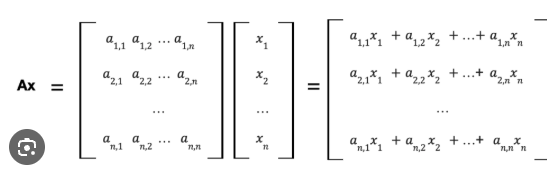

In [43]:
X = df[['A' ,'AD']]
y = df['Y']


#y = A + A*D + e

In [44]:
preds = model.predict(X)

print(preds[:5])

[67.5625 72.5625 67.5625 72.5625 67.5625]


In [45]:
from sklearn.linear_model import LinearRegression

# # X and y
# X = df[['A']]

# y = df['Y']

# model
model = LinearRegression()

model.fit(X, y)

# predictions
preds = model.predict(X)

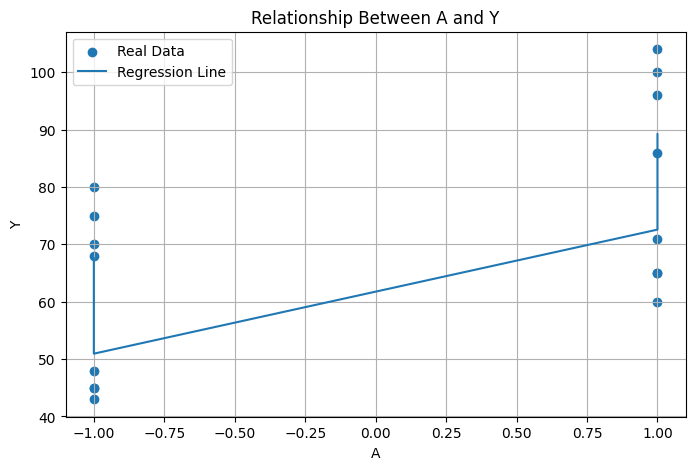

In [46]:
import matplotlib.pyplot as plt

# temp sorted
temp = df[['A', 'Y']].copy()

temp['preds'] = preds

temp = temp.sort_values('A')

# graph
plt.figure(figsize=(8,5))

# real points
plt.scatter(
    temp['A'],
    temp['Y'],
    label='Real Data'
)

# regression line
plt.plot(
    temp['A'],
    temp['preds'],
    label='Regression Line'
)

# labels
plt.xlabel('A')

plt.ylabel('Y')

plt.title('Relationship Between A and Y')

plt.legend()

plt.grid()

plt.show()

In [2]:
# -----------------------------------------------------------------------------
# STEP 1 — MAKE FAKE DATA (so we secretly know the right answer)
#
# We pretend the world works like: y = 2.5 * x + 5 + small messy noise
#   - 2.5  = true slope (each extra hour of practice bumps score about this much)
#   - 5    = true intercept (made-up baseline; not always meaningful in real life)
#   - noise = life is fuzzy: same practice doesn't give the *exact* same score every time
#
# np.random.seed(42) just makes the random numbers repeat the same way each run
#   (handy when you show this to a friend and want the picture to match).
# -----------------------------------------------------------------------------

np.random.seed(42)

n_points = 80  # how many pretend people / days
x = np.random.uniform(0, 10, size=(n_points, 1))  # practice hours between 0 and 10

true_slope = 2.5
true_intercept = 5.0
noise = np.random.normal(0, 2.0, size=(n_points, 1))

y = true_slope * x + true_intercept + noise


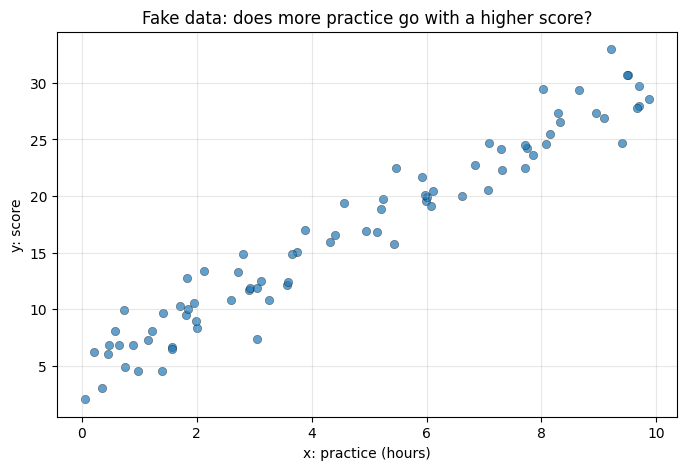

In [3]:
# -----------------------------------------------------------------------------
# STEP 2 — LOOK BEFORE YOU MATH (draw the dots)
#
# If the dots drift upward to the right, x and y "move together" (positive link).
# If you see a sausage shape, a straight line might be a decent summary.
# If the dots look like a banana or a zigzag, a straight line might be the wrong tool
#   — but that's a story for another notebook.
# -----------------------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7, edgecolors="k", linewidths=0.3)
plt.xlabel("x: practice (hours)")
plt.ylabel("y: score")
plt.title("Fake data: does more practice go with a higher score?")
plt.grid(True, alpha=0.3)
plt.show()


In [4]:
# -----------------------------------------------------------------------------
# STEP 3 — FIT THE MODEL (ask sklearn for the best-fit line)
#
# fit(...) means: "learn from these x,y pairs."
# After this, the model stores:
#   coef_      — learned slope (how steep the line is)
#   intercept_ — where the line crosses the y-axis when x = 0
#
# We will compare to the true 2.5 and 5.0 we used to build the data.
# We should get CLOSE, not perfect, because we added noise on purpose.
# -----------------------------------------------------------------------------

model = LinearRegression()
model.fit(x, y)

learned_slope = float(model.coef_[0][0])
learned_intercept = float(model.intercept_[0])

# Tiny sanity print — numbers aren't the lesson; the comments are. Still nice to peek.
print(f"True story we coded:    slope={true_slope}, intercept={true_intercept}")
print(f"What the model learned: slope={learned_slope:.3f}, intercept={learned_intercept:.3f}")


True story we coded:    slope=2.5, intercept=5.0
What the model learned: slope=2.590, intercept=4.562


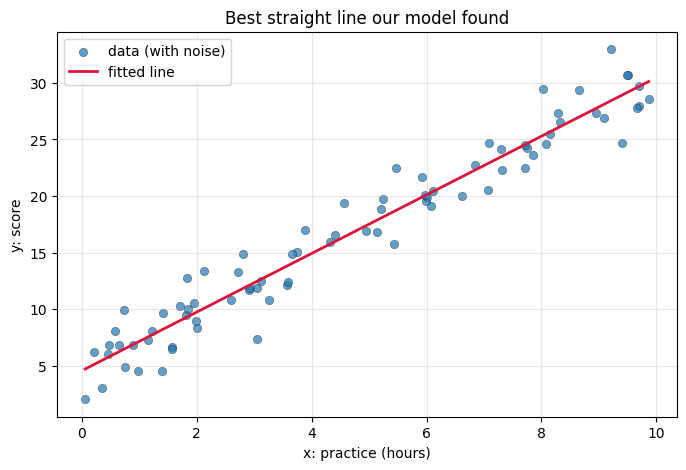

In [5]:
# -----------------------------------------------------------------------------
# STEP 4 — DRAW THE LINE ON TOP OF THE DOTS
#
# The red line is the model's guess for y at every x along the bottom.
# Dots will not sit exactly on the line — that's the noise we added.
# A good line runs through the "middle" of the cloud.
# -----------------------------------------------------------------------------

x_line = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7, label="data (with noise)", edgecolors="k", linewidths=0.3)
plt.plot(x_line, y_line, color="crimson", linewidth=2, label="fitted line")
plt.xlabel("x: practice (hours)")
plt.ylabel("y: score")
plt.title("Best straight line our model found")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


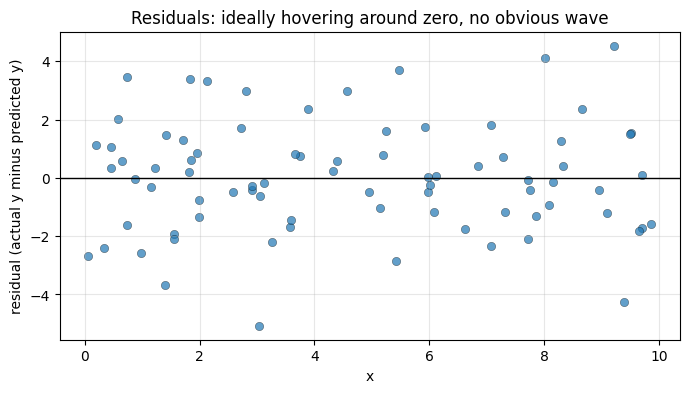

In [6]:
# -----------------------------------------------------------------------------
# STEP 5 — RESIDUALS = "how far off was each guess?"
#
# For each dot: residual = actual y minus predicted y
#   - positive residual: dot sits ABOVE the line (model guessed too low)
#   - negative residual: dot sits BELOW the line (model guessed too high)
#
# We want residuals scattered around zero with no obvious left-right smiley pattern.
# If you see a strong curve here, the straight-line idea might be too simple.
# -----------------------------------------------------------------------------

y_pred = model.predict(x)
residuals = y - y_pred

plt.figure(figsize=(8, 4))
plt.axhline(0, color="black", linewidth=1)
plt.scatter(x, residuals, alpha=0.7, edgecolors="k", linewidths=0.3)
plt.xlabel("x")
plt.ylabel("residual (actual y minus predicted y)")
plt.title("Residuals: ideally hovering around zero, no obvious wave")
plt.grid(True, alpha=0.3)
plt.show()


In [7]:
# -----------------------------------------------------------------------------
# STEP 6 — TWO QUICK SCORECARDS (not for memorizing, for intuition)
#
# MSE (mean squared error): average squared mistake. Big MSE = bigger typical errors.
#   Squaring punishes BIG misses more than small misses — like a video game combo penalty.
#
# R² ("r squared"): rough "how much wiggle in y the line explains" on this dataset.
#   1.0 would mean perfect predictions here; 0 would mean the line is no better than
#   always guessing the average y. Negative R² can happen if the fit is truly awful.
#
# Real projects care more about whether errors are acceptable for the *business* problem,
# not chasing a magic R² number.
# -----------------------------------------------------------------------------

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print(f"MSE (lower is better, same units as y squared): {mse:.3f}")
print(f"R² (higher is usually better on training data, capped at 1 for perfect fit): {r2:.3f}")


MSE (lower is better, same units as y squared): 3.595
R² (higher is usually better on training data, capped at 1 for perfect fit): 0.945


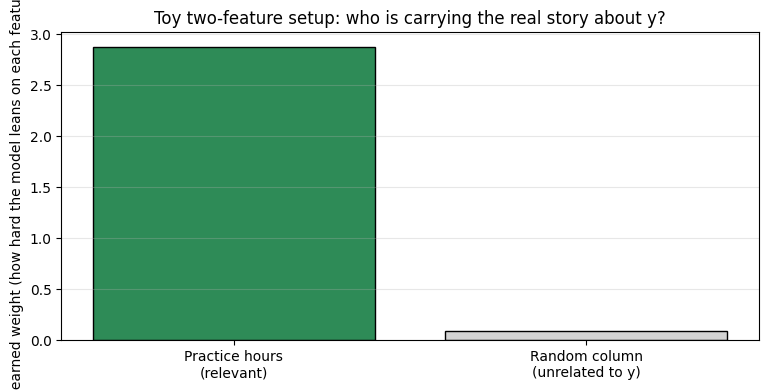

Weight on real driver (truth was 3.0): 2.878
Weight on random junk (ideal would be near 0): 0.087


In [8]:
# -----------------------------------------------------------------------------
# STEP 7 — "Hey Yeriko: filtering features that matter for y vs noise features"
#
# Real tables have MANY columns. Not every column truly helps predict y.
#
# Relevant feature: when it changes, y tends to change with it in a stable way.
# Junk feature: might still look cute in one small sample — random flukes happen —
#   but it doesn't carry real signal (or it's duplicated by another column).
#
# What people do in practice (human version):
#   - Plot each x against y; ask "does this relationship make real-world sense?"
#   - Try models on fresh data (validation). If adding a column doesn't help there,
#     it might be noise for your setup.
#   - Ridge/Lasso: politely shrink weak coefficients; Lasso can zero some out = "ignore."
#   - Tree models can show feature importance / permutation importance — different idea
#     than a straight line, but great for "what mattered for predictions?"
#
# Demo: one column REALLY builds y; second column is pure random, unrelated.
# We hope the learned weight on the junk column stays small compared to the real one.
# -----------------------------------------------------------------------------

np.random.seed(7)
n2 = 120
x_relevant = np.random.uniform(0, 10, size=(n2, 1))
x_useless = np.random.uniform(0, 10, size=(n2, 1))

# Only x_relevant belongs in the true recipe; x_useless is dice rolls dressed as a column
y2 = 3.0 * x_relevant + 8.0 + np.random.normal(0, 2.5, size=(n2, 1))

X_both = np.hstack([x_relevant, x_useless])

model2 = LinearRegression()
model2.fit(X_both, y2)

coef_relevant = float(model2.coef_[0][0])
coef_useless = float(model2.coef_[0][1])

plt.figure(figsize=(9, 4))
plt.bar(
    ["Practice hours\n(relevant)", "Random column\n(unrelated to y)"],
    [coef_relevant, coef_useless],
    color=["seagreen", "lightgray"],
    edgecolor="k",
)
plt.ylabel("learned weight (how hard the model leans on each feature)")
plt.title("Toy two-feature setup: who is carrying the real story about y?")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

print(f"Weight on real driver (truth was 3.0): {coef_relevant:.3f}")
print(f"Weight on random junk (ideal would be near 0): {coef_useless:.3f}")
